# Практическая работа: Обработка изображений в градациях серого
**Цель работы:**
1. Загрузить изображение в оттенках серого `sar_1_gray.jpg`.
2. Построить гистограмму яркости.
3. Реализовать алгоритм гамма-коррекции `($\gamma < 1$ и $\gamma > 1$)`.


4. Сравнить исходное и скорректированные изображения (метрики MSE, SSIM).
5. Реализовать алгоритм статистической цветокоррекции на основе выравнивания гистограммы (eq_gray).
6. Протестировать работу алгоритмов пороговой фильтрации с различными параметрами.

In [20]:
# Импорт необходимых библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim
from google.colab import files
import os



In [30]:
# Код для загрузки файлов с вашего компьютера
uploaded = files.upload()

Saving sar_1_gray.jpg to sar_1_gray (5).jpg


## Задание 1. Загрузка изображения в оттенках серого


Разрешение изображения: (400, 600)
Тип данных: uint8
Диапазон яркости: от 0 до 255


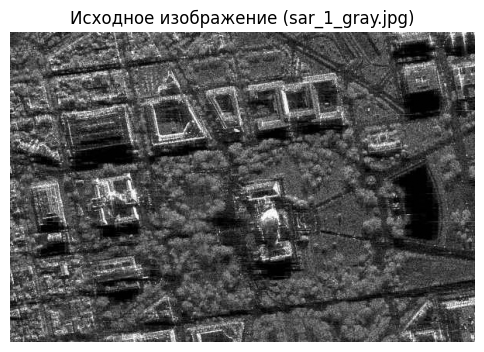

In [31]:
# Чтение изображения в режиме градаций серого (1 канал)
img_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

# Проверка корректности загрузки
if img_gray is None:
    raise FileNotFoundError("Ошибка: файл sar_1_gray.jpg не найден или поврежден.")

print(f"Разрешение изображения: {img_gray.shape}")
print(f"Тип данных: {img_gray.dtype}")
print(f"Диапазон яркости: от {img_gray.min()} до {img_gray.max()}")

# Отображение исходного изображения
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.title("Исходное изображение (sar_1_gray.jpg)")
plt.axis('off')
plt.show()

## Задание 2. Построение гистограммы распределения яркости


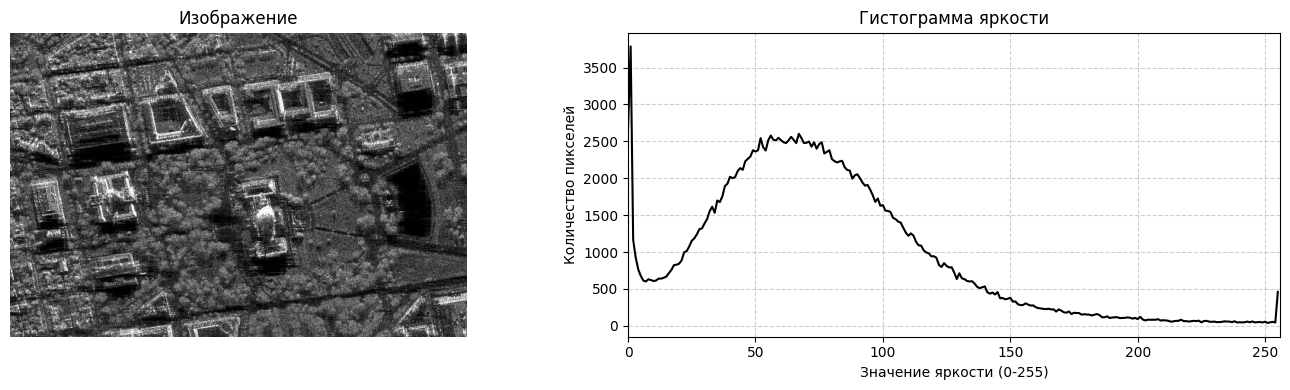

In [23]:
# Вычисление гистограммы с помощью OpenCV
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Изображение")
axes[0].axis('off')

axes[1].plot(hist, color='black')
axes[1].set_xlim([0, 256])
axes[1].set_title("Гистограмма яркости")
axes[1].set_xlabel("Значение яркости (0-255)")
axes[1].set_ylabel("Количество пикселей")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Задание 3. Алгоритм гамма-коррекции
`($\gamma < 1$ и $\gamma > 1$)`

Гамма-коррекция выполняется по формуле:
$$I_{out} = 255 \times \left(\frac{I_{in}}{255}\right)^\gamma$$
`$$I_{out} = 255 \times \left(\frac{I_{in}}{255}\right)^\gamma$$`

Для оптимизации вычислений строится таблица соответствия (LUT).

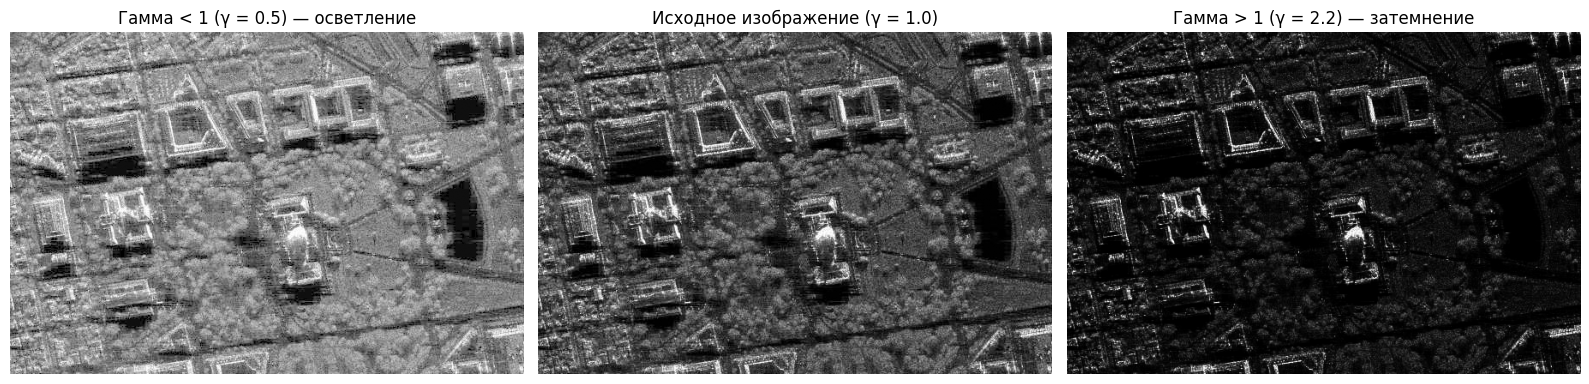

In [24]:
def apply_gamma_correction(image: np.ndarray, gamma: float) -> np.ndarray:
    # Таблица пересчета значений 0..255
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

# Параметры гаммы
gamma_low = 0.5   # Осветление темных участков
gamma_high = 2.2  # Затемнение и повышение контраста ярких областей

img_gamma_low = apply_gamma_correction(img_gray, gamma_low)
img_gamma_high = apply_gamma_correction(img_gray, gamma_high)

# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_gamma_low, cmap='gray')
axes[0].set_title(f"Гамма < 1 (γ = {gamma_low}) — осветление")
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Исходное изображение (γ = 1.0)")
axes[1].axis('off')

axes[2].imshow(img_gamma_high, cmap='gray')
axes[2].set_title(f"Гамма > 1 (γ = {gamma_high}) — затемнение")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Задание 4. Оценка различий с помощью метрик MSE и SSIM
* **MSE (Mean Squared Error)** — среднеквадратичная ошибка (чем ближе к 0, тем ближе изображения).
* **SSIM (Structural Similarity Index)** — индекс структурного сходства (принимает значения от -1 до 1; 1 означает идентичность).

In [25]:
# Расчет метрик
mse_val_low = mse(img_gray, img_gamma_low)
ssim_val_low = ssim(img_gray, img_gamma_low)

mse_val_high = mse(img_gray, img_gamma_high)
ssim_val_high = ssim(img_gray, img_gamma_high)

# Вывод результатов в виде таблицы
print("=" * 65)
print(f"{'Сравнение':<30} | {'MSE':<12} | {'SSIM':<12}")
print("-" * 65)
print(f"{f'Исходное vs Гамма {gamma_low}':<30} | {mse_val_low:<12.2f} | {ssim_val_low:<12.4f}")
print(f"{f'Исходное vs Гамма {gamma_high}':<30} | {mse_val_high:<12.2f} | {ssim_val_high:<12.4f}")
print("=" * 65)

Сравнение                      | MSE          | SSIM        
-----------------------------------------------------------------
Исходное vs Гамма 0.5          | 3250.43      | 0.7875      
Исходное vs Гамма 2.2          | 2894.08      | 0.4356      


## Задание 5. Статистическая цветокоррекция

(выравнивание гистограммы `eq_gray`)
Используется метод эквализации гистограммы (`cv2.equalizeHist`), который преобразует распределение яркостей к равномерному, улучшая контраст.

Статистические показатели:
• Исходное:    Средняя яркость = 74.94, СКО = 43.66
• Эквализация: Средняя яркость = 127.03, СКО = 74.27



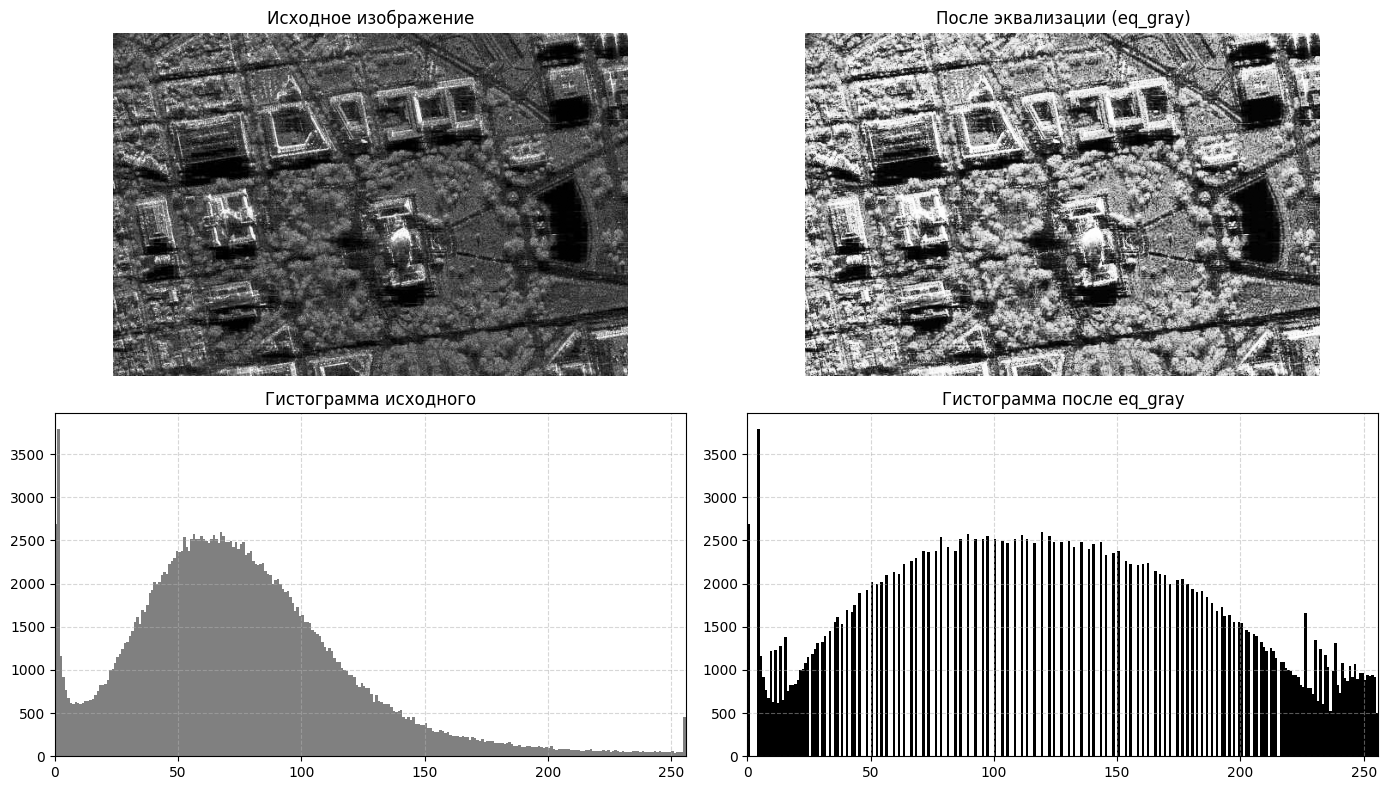

In [26]:
# Применение эквализации гистограммы
img_eq_gray = cv2.equalizeHist(img_gray)

# Расчет статистических характеристик
mean_orig, std_orig = np.mean(img_gray), np.std(img_gray)
mean_eq, std_eq = np.mean(img_eq_gray), np.std(img_eq_gray)

print("Статистические показатели:")
print(f"• Исходное:    Средняя яркость = {mean_orig:.2f}, СКО = {std_orig:.2f}")
print(f"• Эквализация: Средняя яркость = {mean_eq:.2f}, СКО = {std_eq:.2f}\n")

# Отображение изображений и их гистограмм
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("Исходное изображение")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_eq_gray, cmap='gray')
axes[0, 1].set_title("После эквализации (eq_gray)")
axes[0, 1].axis('off')

axes[1, 0].hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 0].set_title("Гистограмма исходного")
axes[1, 0].set_xlim([0, 256])
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].hist(img_eq_gray.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 1].set_title("Гистограмма после eq_gray")
axes[1, 1].set_xlim([0, 256])
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Задание 6. Пороговая фильтрация с различными параметрами
Тестируются следующие подходы:
1. **Глобальный порог**: фиксированные значения (50, 127, 180).
2. **Метод Оцу (Otsu)**: автоматический расчет глобального порога на основе гистограммы.
3. **Адаптивные пороги**: расчет порога по локальной окрестности каждого пикселя (`Mean` и `Gaussian`).

Порог, определенный методом Оцу: 85.00


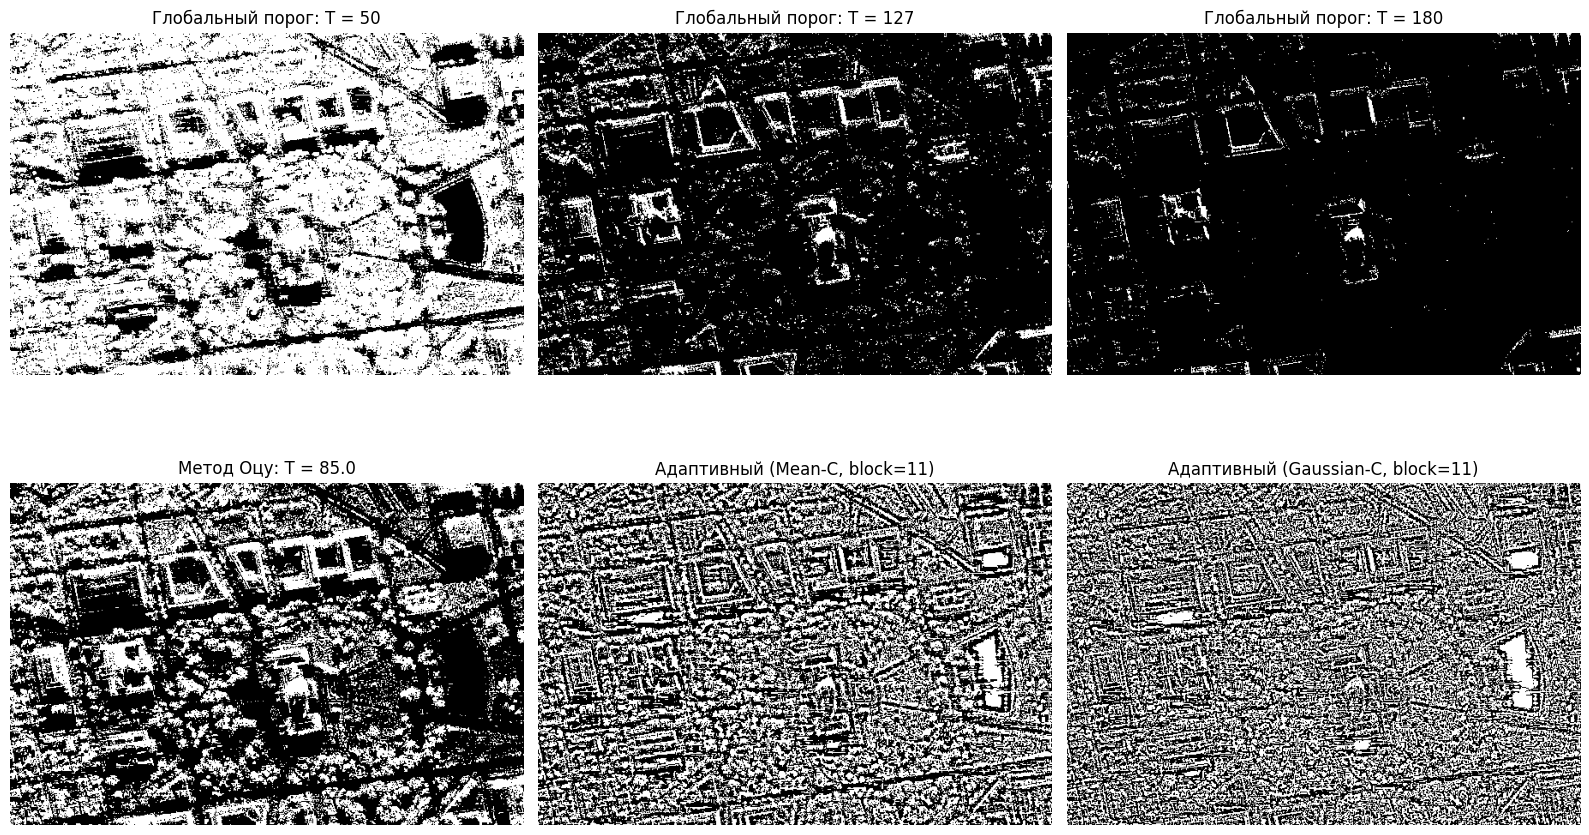

In [27]:
# 1. Фиксированная глобальная бинаризация
_, thresh_50 = cv2.threshold(img_gray, 50, 255, cv2.THRESH_BINARY)
_, thresh_127 = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
_, thresh_180 = cv2.threshold(img_gray, 180, 255, cv2.THRESH_BINARY)

# 2. Автоматический порог Оцу
otsu_thresh, thresh_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Порог, определенный методом Оцу: {otsu_thresh:.2f}")

# 3. Адаптивная пороговая фильтрация (окно 11x11, C = 2)
thresh_adapt_mean = cv2.adaptiveThreshold(
    img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
)
thresh_adapt_gauss = cv2.adaptiveThreshold(
    img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# Визуализация всех вариантов
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(thresh_50, cmap='gray')
axes[0, 0].set_title("Глобальный порог: T = 50")
axes[0, 0].axis('off')

axes[0, 1].imshow(thresh_127, cmap='gray')
axes[0, 1].set_title("Глобальный порог: T = 127")
axes[0, 1].axis('off')

axes[0, 2].imshow(thresh_180, cmap='gray')
axes[0, 2].set_title("Глобальный порог: T = 180")
axes[0, 2].axis('off')

axes[1, 0].imshow(thresh_otsu, cmap='gray')
axes[1, 0].set_title(f"Метод Оцу: T = {otsu_thresh:.1f}")
axes[1, 0].axis('off')

axes[1, 1].imshow(thresh_adapt_mean, cmap='gray')
axes[1, 1].set_title("Адаптивный (Mean-C, block=11)")
axes[1, 1].axis('off')

axes[1, 2].imshow(thresh_adapt_gauss, cmap='gray')
axes[1, 2].set_title("Адаптивный (Gaussian-C, block=11)")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

##Для 2 изображения повторим те же действоия